In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from queuing_model.queuing_model import queue_max_lambda, queue_min_servers, queue_sweep_rho

In [2]:
Path('figs').mkdir(exist_ok=True)

In [12]:
lambda_target = 5
waiting_times_min = [5, 10, 15, 20]


queue_min_servers(lambda_target=lambda_target, charging_time_min=45, stdev_ct_min=10,waiting_times_min=waiting_times_min,method='lee_longton', output_unit='hours_to_minutes')

(5.0, {'5.0': 6, '10.0': 5, '15.0': 5, '20.0': 5})

In [13]:
queue_25_lee = queue_max_lambda(charging_time_min=25, stdev_ct_min=10, mean_waiting_time_min=5, max_server=32, method='lee_longton', output_unit='hours_to_minutes')

In [14]:
queue_25_lee

,servers,lambda,roh,wq_mmc,wq_mgc,wz/az
1,1.0,0.615380,0.256408,4.999952,4.999952,0.199998
2,2.0,2.430466,0.506347,8.619658,4.999402,0.199976
3,3.0,4.499995,0.624999,8.608783,4.993094,0.199724
4,4.0,6.671185,0.694915,8.620561,4.999925,0.199997
5,5.0,8.893058,0.741088,8.616899,4.997801,0.199912
6,6.0,11.149354,0.774261,8.619862,4.999520,0.199981
7,7.0,13.427990,0.799285,8.619866,4.999522,0.199981
8,8.0,15.723031,0.818908,8.618468,4.998712,0.199948
9,9.0,18.031183,0.834777,8.618709,4.998851,0.199954
10,10.0,20.349589,0.847900,8.619716,4.999435,0.199977


In [6]:
queue_25_lee.to_csv('warteschlange_lee_25_10_5_32.csv')

In [15]:
queue_25_allen = queue_max_lambda(charging_time_min=25, stdev_ct_min=10, mean_waiting_time_min=5, max_server=32, method='allen_cunneen', c_a2=1.5, output_unit='hours_to_minutes')

In [16]:
queue_25_allen

,servers,lambda,roh,wq_mmc,wq_gigc,wz/az
1,1.0,0.465966,0.194153,3.493482,4.999293,0.199972
2,2.0,2.114060,0.440429,6.016520,4.993712,0.199748
3,3.0,4.080318,0.566711,6.023366,4.999393,0.199976
4,4.0,6.170795,0.642791,6.023725,4.999692,0.199988
5,5.0,8.329093,0.694091,6.022782,4.998909,0.199956
6,6.0,10.531044,0.731323,6.023544,4.999542,0.199982
7,7.0,12.761999,0.759643,6.021119,4.997529,0.199901
8,8.0,15.016684,0.782119,6.023951,4.999880,0.199995
9,9.0,17.286311,0.800292,6.020812,4.997274,0.199891
10,10.0,19.570293,0.815429,6.020411,4.996941,0.199878


In [14]:
queue_25_allen.to_csv('warteschlange_allen_25_10_5_32.csv')

In [17]:
roh_range = np.arange(0.002, 0.999, 0.002)
ladezeit = 25

queue_2_server = queue_sweep_rho(roh_range, 2, charging_time_min=ladezeit, stdev_ct_min=10, method='lee_longton', output_unit='hours_to_minutes')
queue_4_server = queue_sweep_rho(roh_range, 4, charging_time_min=ladezeit, stdev_ct_min=10, method='lee_longton', output_unit='hours_to_minutes')
queue_8_server = queue_sweep_rho(roh_range, 8, charging_time_min=ladezeit, stdev_ct_min=10, method='lee_longton', output_unit='hours_to_minutes')
queue_10_server = queue_sweep_rho(roh_range, 10, charging_time_min=ladezeit, stdev_ct_min=10, method='lee_longton',output_unit='hours_to_minutes')
queue_15_server = queue_sweep_rho(roh_range, 15, charging_time_min=ladezeit, stdev_ct_min=10, method='lee_longton', output_unit='hours_to_minutes')
queue_20_server = queue_sweep_rho(roh_range, 20, charging_time_min=ladezeit, stdev_ct_min=10, method='lee_longton', output_unit='hours_to_minutes')

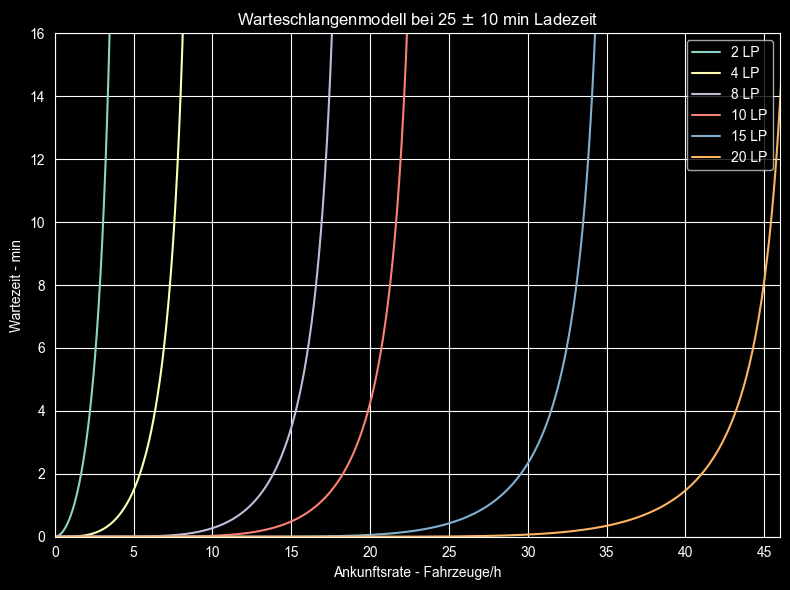

In [18]:
fig, ax = plt.subplots(figsize=(8,6), nrows=1, ncols=1)
sns.lineplot(x='lambda', y='wq_mgc', data=queue_2_server, ax=ax, label='2 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_4_server, ax=ax, label='4 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_8_server, ax=ax, label='8 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_10_server, ax=ax, label='10 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_15_server, ax=ax, label='15 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_20_server, ax=ax, label='20 LP')
plt.ylim(0, 16)
plt.xlim(0, 46)
plt.xticks(np.arange(0, 46, 5))
#plt.yscale('log')
plt.xlabel('Ankunftsrate - Fahrzeuge/h')
plt.ylabel('Wartezeit - min')
plt.title(f'Warteschlangenmodell bei {ladezeit} $\pm$ 10 min Ladezeit')
plt.legend()
plt.tight_layout()
plt.savefig(f'figs/warte_{ladezeit}_ankunft_vs_zeit.jpg')
plt.show()

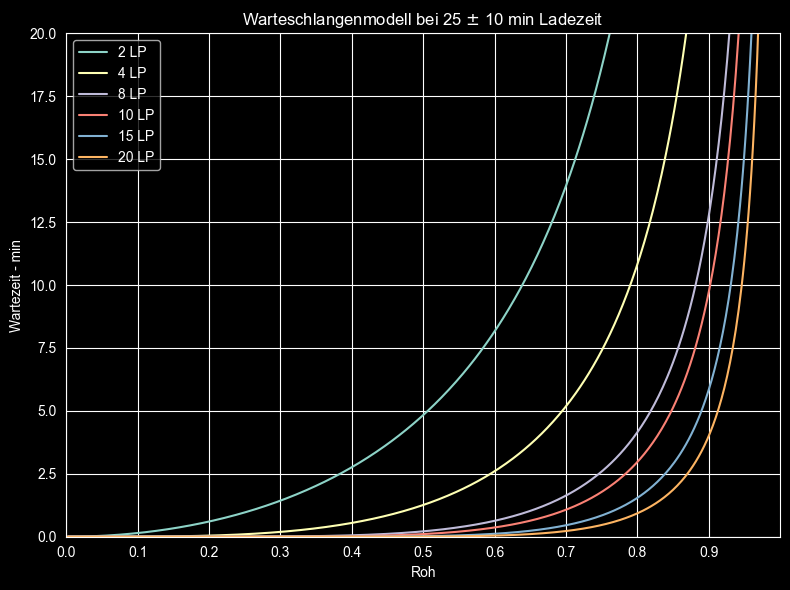

In [19]:
fig, ax = plt.subplots(figsize=(8,6), nrows=1, ncols=1)
sns.lineplot(x='rho', y='wq_mgc', data=queue_2_server, ax=ax, label='2 LP')
sns.lineplot(x='rho', y='wq_mgc', data=queue_4_server, ax=ax, label='4 LP')
sns.lineplot(x='rho', y='wq_mgc', data=queue_8_server, ax=ax, label='8 LP')
sns.lineplot(x='rho', y='wq_mgc', data=queue_10_server, ax=ax, label='10 LP')
sns.lineplot(x='rho', y='wq_mgc', data=queue_15_server, ax=ax, label='15 LP')
sns.lineplot(x='rho', y='wq_mgc', data=queue_20_server, ax=ax, label='20 LP')
plt.ylim(0, 20)
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1, 0.1))
#plt.yscale('log')
plt.xlabel('Roh')
plt.ylabel('Wartezeit - min')
plt.title(f'Warteschlangenmodell bei {ladezeit} $\pm$ 10 min Ladezeit')
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
queue_20_server[(queue_20_server['rho'] > 0.75) & (queue_20_server['rho'] < 0.85)]

,rho,lambda,servers,wq_mmc,wq_mgc,wz/az
375,0.752,36.096,20,0.824945,0.478468,0.019139
376,0.754,36.192,20,0.848350,0.492043,0.019682
377,0.756,36.288,20,0.872379,0.505980,0.020239
378,0.758,36.384,20,0.897048,0.520288,0.020812
379,0.760,36.480,20,0.922376,0.534978,0.021399
380,0.762,36.576,20,0.948380,0.550060,0.022002
381,0.764,36.672,20,0.975079,0.565546,0.022622
382,0.766,36.768,20,1.002494,0.581446,0.023258
383,0.768,36.864,20,1.030643,0.597773,0.023911
384,0.770,36.960,20,1.059548,0.614538,0.024582


In [20]:
ladezeit_que = 25
queue_warte_1 = queue_max_lambda(charging_time_min=ladezeit_que, stdev_ct_min=10, mean_waiting_time_min=1, max_server=32, method='lee_longton', output_unit='hours_to_minutes')
queue_warte_2 = queue_max_lambda(charging_time_min=ladezeit_que, stdev_ct_min=10, mean_waiting_time_min=2, max_server=32, method='lee_longton', output_unit='hours_to_minutes')
queue_warte_5 = queue_max_lambda(charging_time_min=ladezeit_que, stdev_ct_min=10, mean_waiting_time_min=5, max_server=32, method='lee_longton', output_unit='hours_to_minutes')
queue_warte_10 = queue_max_lambda(charging_time_min=ladezeit_que, stdev_ct_min=10, mean_waiting_time_min=10, max_server=32, method='lee_longton', output_unit='hours_to_minutes')
queue_warte_15 = queue_max_lambda(charging_time_min=ladezeit_que, stdev_ct_min=10, mean_waiting_time_min=15, max_server=32, method='lee_longton', output_unit='hours_to_minutes')

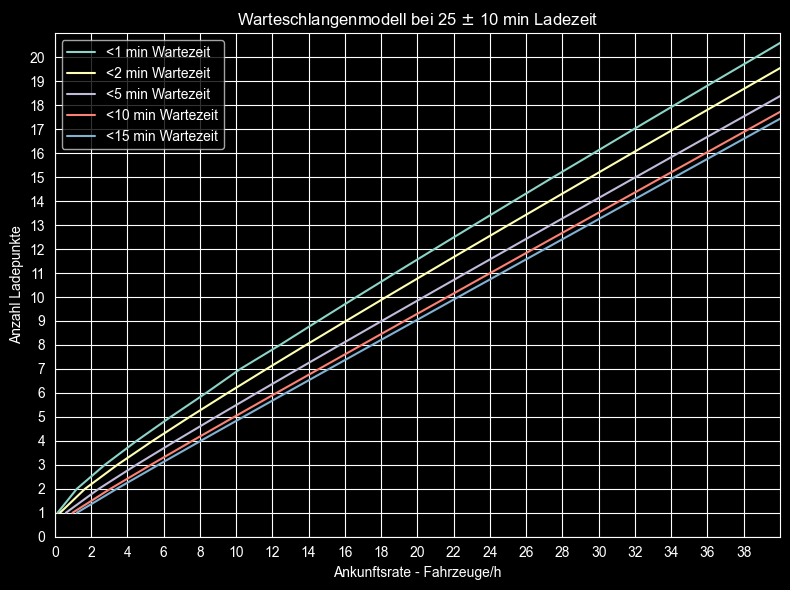

In [21]:
fig, ax = plt.subplots(figsize=(8,6), nrows=1, ncols=1)
sns.lineplot(x='lambda', y='servers', data=queue_warte_1, ax=ax, label='<1 min Wartezeit')
sns.lineplot(x='lambda', y='servers', data=queue_warte_2, ax=ax, label='<2 min Wartezeit')
sns.lineplot(x='lambda', y='servers', data=queue_warte_5, ax=ax, label='<5 min Wartezeit')
sns.lineplot(x='lambda', y='servers', data=queue_warte_10, ax=ax, label='<10 min Wartezeit')
sns.lineplot(x='lambda', y='servers', data=queue_warte_15, ax=ax, label='<15 min Wartezeit')
plt.ylim(0, 21)
plt.xlim(0, 40)
plt.xticks(np.arange(0, 40, 2))
plt.yticks(np.arange(0, 21, 1))
plt.ylabel('Anzahl Ladepunkte')
plt.xlabel('Ankunftsrate - Fahrzeuge/h')
plt.legend()
plt.title(f'Warteschlangenmodell bei {ladezeit_que} $\pm$ 10 min Ladezeit')
plt.tight_layout()
#plt.savefig(f'figs/warte_{ladezeit_que}_ankunft_vs_ladepunkte.jpg')
plt.show()

In [22]:
queue_warte_5

,servers,lambda,roh,wq_mmc,wq_mgc,wz/az
1,1.0,0.615380,0.256408,4.999952,4.999952,0.199998
2,2.0,2.430466,0.506347,8.619658,4.999402,0.199976
3,3.0,4.499995,0.624999,8.608783,4.993094,0.199724
4,4.0,6.671185,0.694915,8.620561,4.999925,0.199997
5,5.0,8.893058,0.741088,8.616899,4.997801,0.199912
6,6.0,11.149354,0.774261,8.619862,4.999520,0.199981
7,7.0,13.427990,0.799285,8.619866,4.999522,0.199981
8,8.0,15.723031,0.818908,8.618468,4.998712,0.199948
9,9.0,18.031183,0.834777,8.618709,4.998851,0.199954
10,10.0,20.349589,0.847900,8.619716,4.999435,0.199977
